In [113]:
from dlfs.base import Module, Loss, Optimizer, Layer

from dlfs.modules import SequentialWrapper
from dlfs.layers import DenseLayer, ConvLayer, ConvTransposeLayer, MaxPoolLayer
from dlfs.activation import ReLU, Sigmoid, GELU, LeakyReLU, TanH

from dlfs.loss import MSE_Loss, BCE_Loss
from dlfs.optimizers import Optimizer_Adam, Optimizer_AdamW
from dlfs.helpers import im2col, col2im, im2col_strided, col2im_strided, get_random_batch, load_mnist, select_mnist_labels, preprocess_whole_mnist

import numpy as np
import matplotlib.pyplot as plt

In [114]:
class DiffusionModelo(Module):

    def __init__(self):
        self.fc1 = DenseLayer(1, 32)
        self.fc2 = DenseLayer(32, 32)
        self.fc3 = DenseLayer(32, 1)

        self.relu1 = ReLU()
        self.relu2 = ReLU()
        
    def forward(self, x, t, training=False):
        # x: noisy data, t: timestep
        x = np.concatenate([x, t], axis=0)

        self.fc1.forward(x)
        self.relu1.forward(self.fc1.output)

        self.fc2.forward(self.relu1.output)
        self.relu2.forward(self.fc2.output)

        self.fc3.forward(self.relu2.output)
        self.output = self.fc3.output

    def backward(self, delta):
        self.fc3.backward(delta)

        self.relu2.backward(self.fc3.dinputs)
        self.fc2.backward(self.relu2.dinputs)

        self.relu1.backward(self.fc2.dinputs)
        self.fc1.backward(self.relu1.dinputs)
        self.dinputs = self.fc1.dinputs

In [115]:
class Diffusion(Module):

    def __init__(self, model, image_size=28, image_channels=3, timesteps=1000, t_emb_dim=128, loss_function=None, optimizer=None):
        self.model = model
        self.timesteps = timesteps
        self.image_size = image_size

        self.betas = np.linspace(1e-4, 0.02, timesteps)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = np.cumprod(self.alphas, axis=0)

        self.ac = np.sqrt(self.alphas_cumprod)
        self.om = np.sqrt(1 - self.alphas_cumprod)

        self.image_channels = image_channels
        self.t_emb_dim = t_emb_dim

        self.loss_function = loss_function
        self.optimizer = optimizer

        self.tanh = TanH()


    def forward_diffusion(self, x0, t):

        # Compute coefficients for each batch item
        # reshape to (batch, 1, 1, 1) for broadcasting
        ac_t = self.ac[t].reshape(-1, 1)
        om_t = self.om[t].reshape(-1, 1)

        # Sample noise of same shape as x0
        noise = np.random.randn(*x0.shape)

        # Forward diffusion formula
        x_t = ac_t * x0 + om_t * noise

        return x_t, noise

    def forward(self, x, training=False):

        B, C = x.shape[:2]

        # Generate random timesteps
        t = np.random.rand(B, 1)
        noise = np.random.randn(*x.shape)

        x_t = x + noise

        print(f'xt: {x_t.shape}')

        print(f'temb: {t.shape}')

        self.model.forward(x_t, t, training=training)
        self.output = self.model.output
        self.noise_output = noise

    def backward(self, predicted, noise):

        self.loss_function.backward(predicted, noise)
        self.model.backward(self.loss_function.dinputs)

    def print_grads(self, layer):

        if isinstance(layer, Layer):
            params = layer.get_parameters()
            if params is None:
                return

            for name in params:
                param = getattr(layer, 'd'+name)
                print(f'{layer.__class__.__name__} grad {name}: {np.linalg.norm(param)}')

        if isinstance(layer, list):
            for l in layer:
                self.print_grads(l)

        if isinstance(layer, Module):
            for name, attr in vars(layer).items():
                self.print_grads(attr)

    def train(self, X: np.ndarray, epochs = 1000, batch_size: int = None, print_every: int = None) -> None:

        # Store loss values for plotting
        self.loss_vals = []

        for i in range(epochs + 1):

            if batch_size is not None:
                batch_X = get_random_batch(X, y, batch_size=batch_size)
            else:
                # If batch size is not specified take the whole dataset
                batch_X = X

            # Forward pass
            self.forward(batch_X, training=True)

            # Backward pass
            self.backward(self.output, self.noise_output)

            # Update parameters
            self.optimizer.pre_update_parameters()
            self.optimizer.update_parameters(self)
            self.optimizer.post_update_parameters()

            #self.print_grads(self)

            # Store current loss
            loss = self.loss_function.calculate(self.output, self.noise_output)
            self.loss_vals.append(loss)

            if print_every is not None and not i % print_every:
                print(f'===== EPOCH : {i} ===== LOSS : {loss} ===== mu: {np.mean(self.output)} std: {np.std(self.output)}')

    def generate(self, B, C, H, W):
        
        x_t = np.random.randn(B, C, H, W).astype(np.float32)  # start from pure Gaussian noise

        for t in reversed(range(self.timesteps)):
            t_arr = np.array([t] * B)
            
            # Compute timestep embedding
            t_emb = self.get_timestep_embedding(t_arr, dim=self.t_emb_dim)
            
            # Predict noise
            self.model.forward(x_t, t_emb, training=False)
            epsilon_pred = self.model.output
            
            # DDPM reverse diffusion formula
            alpha_t = self.alphas[t]
            alpha_cumprod_t = self.alphas_cumprod[t]
            beta_t = self.betas[t]
            
            # Predict mean of x_{t-1}
            mean = (1 / np.sqrt(alpha_t)) * (x_t - (beta_t / np.sqrt(1 - alpha_cumprod_t)) * epsilon_pred)
            
            # Sample x_{t-1} with noise if t > 0
            if t > 0:
                noise = np.random.randn(*x_t.shape)
                x_t = mean + np.sqrt(beta_t) * noise
            else:
                x_t = mean

        generated_images = x_t  # shape: (B, C, H, W)
        #images_uint8 = (np.clip(generated_images, 0, 1) * 255).astype(np.uint8)

        return generated_images

In [116]:
data = np.linspace(-1, 1, 16)  # shape: [16,1]
data = np.expand_dims(data, axis=1)
target = data ** 3  # some simple transformation as the "true" signal

print(data.shape)
print(target.shape)

(16, 1)
(16, 1)


In [117]:
lr=1e-3
epochs=1000

loss = MSE_Loss()
optimizer = Optimizer_Adam(learning_rate=lr, clip_grad=False)

unet = DiffusionModelo() #U_Net(img_channels=1, base_channels=3) # TinyUNet(image_channels=1)

diffusion = Diffusion(model=unet, image_channels=1, t_emb_dim=1, loss_function=loss, optimizer=optimizer)

diffusion.train(data, print_every=1)

xt: (16, 1)
temb: (16, 1)


ValueError: operands could not be broadcast together with shapes (32,1) (16,1) 

In [ ]:
batch_X = X_train
batch_size = batch_X.shape[0]

x_t, noise = diffusion.forward_diffusion(X_train, np.zeros(batch_size, dtype=int))
diffusion.forward(X_train)
print(diffusion.model.output.mean(), diffusion.model.output.std())

-4.0007468282328205 1.586385478339541


In [ ]:
new_images = diffusion.generate(10, 1, 28, 28)

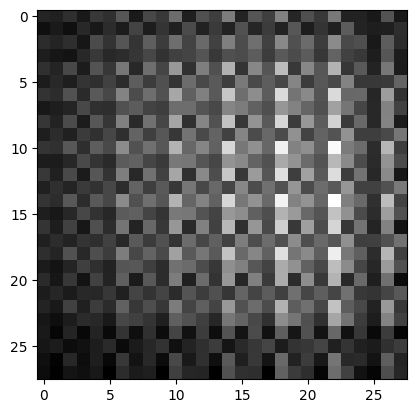

In [ ]:
idx = np.random.randint(10)

img = (new_images[idx] + 1) * 127.5
img = img.reshape(28, 28)

plt.imshow(img, cmap='gray')
plt.show()